In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df_res = pd.read_csv('final_data/simulation_results.csv')

In [3]:
df_res["v_type"].unique()

<StringArray>
['const', 'var_025', 'var_05', 'var_1', 'var_2', 'var_3']
Length: 6, dtype: str

In [6]:
summary_df = (
    df_res
    .groupby(['v_type', 't', 'm'])[['critical_v', 'pays']]
    .mean()
    .groupby(['v_type', 'm'])
    .mean()
    .reset_index()
)

summary_df.to_csv('summary_results.csv', index=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


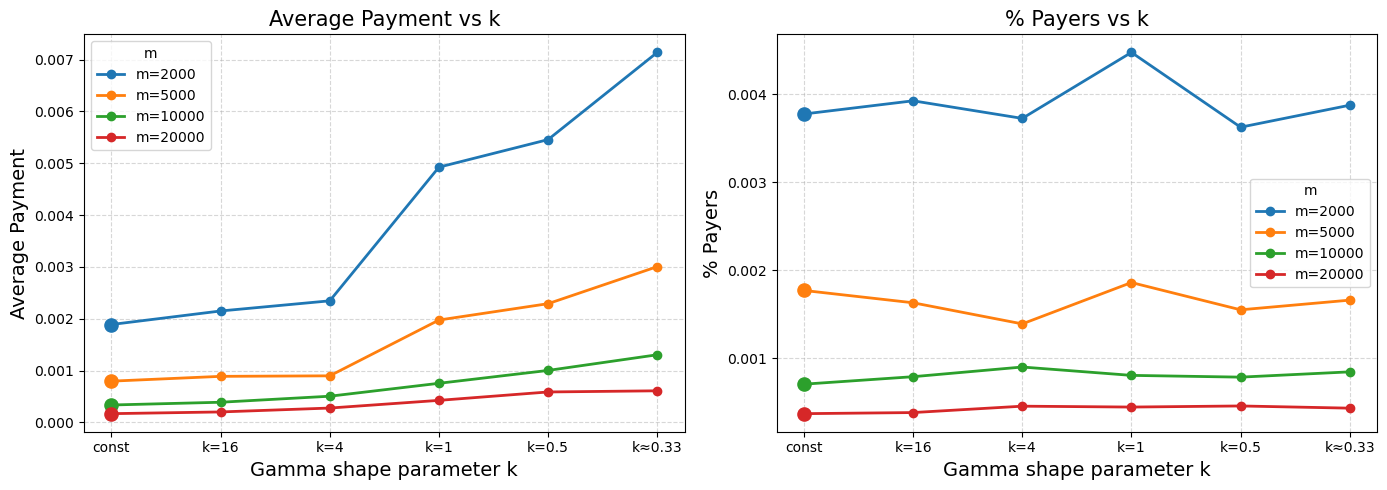

In [8]:
import matplotlib.pyplot as plt

order = ['const', 'var_025', 'var_05', 'var_1', 'var_2', 'var_3']

k_labels = [
    'const',
    'k=16',
    'k=4',
    'k=1',
    'k=0.5',
    'k≈0.33'
]

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c',
    '#d62728', '#9467bd', '#8c564b'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# =========================================================
# LEFT PLOT: critical_v
# =========================================================
for idx, (m, df_m) in enumerate(summary_df.groupby('m')):
    c = colors[idx % len(colors)]

    df_m = (
        df_m.set_index('v_type')
        .reindex(order)
        .reset_index()
    )

    x = range(len(order))

    axes[0].plot(
        x,
        df_m['critical_v'],
        marker='o',
        linewidth=2,
        color=c,
        label=f'm={m}'
    )

    const_idx = order.index('const')
    axes[0].scatter(
        const_idx,
        df_m.loc[const_idx, 'critical_v'],
        color=c,
        s=90,
        zorder=3
    )

axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(k_labels)
axes[0].set_xlabel('Gamma shape parameter k', fontsize=14)
axes[0].set_ylabel('Average Payment', fontsize=14)
axes[0].set_title('Average Payment vs k', fontsize=15)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='m')


# =========================================================
# RIGHT PLOT: pays
# =========================================================
for idx, (m, df_m) in enumerate(summary_df.groupby('m')):
    c = colors[idx % len(colors)]

    df_m = (
        df_m.set_index('v_type')
        .reindex(order)
        .reset_index()
    )

    x = range(len(order))

    axes[1].plot(
        x,
        df_m['pays'],
        marker='o',
        linewidth=2,
        color=c,
        label=f'm={m}'
    )

    const_idx = order.index('const')
    axes[1].scatter(
        const_idx,
        df_m.loc[const_idx, 'pays'],
        color=c,
        s=90,
        zorder=3
    )

axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(k_labels)
axes[1].set_xlabel('Gamma shape parameter k', fontsize=14)
axes[1].set_ylabel('% Payers', fontsize=14)
axes[1].set_title('% Payers vs k', fontsize=15)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='m')

# =========================================================
plt.tight_layout()

plt.savefig('critical_v_and_pays_by_k.png')
plt.savefig('critical_v_and_pays_by_k.eps')
plt.savefig('critical_v_and_pays_by_k.pdf')
plt.savefig('critical_v_and_pays_by_k.jpg')

plt.show()